# 04. Baseline Trajectory Forecasting Models
**Project:** Where Will This Vessel Be in 4–6 Hours?  
**Author:** Praneeth (ED23B032)  
**Assignment:** Blurgs.ai Take-Home  

---

### Baseline Formulations
In this notebook, we implement and test three foundational physical and statistical baselines in local metric tangent plane $(x, y)$:

1. **Linear Velocity Extrapolation:**
   Estimates empirical velocity over the recent history window (last 30–45 minutes up to origin $T$):
   $$\hat{v}_x = \frac{\sum (t_i - \bar{t})(x_i - \bar{x})}{\sum (t_i - \bar{t})^2}, \quad \hat{v}_y = \frac{\sum (t_i - \bar{t})(y_i - \bar{y})}{\sum (t_i - \bar{t})^2}$$
   $$\hat{x}(T + \tau) = x_0 + \hat{v}_x \cdot \tau, \quad \hat{y}(T + \tau) = y_0 + \hat{v}_y \cdot \tau$$

2. **Polynomial Extrapolation (Degree 2):**
   Fits independent quadratic polynomials centered at origin $T$ ($t \in [-4\text{h}, 0]$):
   $$x(t) \approx a_x t^2 + b_x t + c_x, \quad y(t) \approx a_y t^2 + b_y t + c_y$$
   Evaluating at future times $+4\text{h}$ and $+6\text{h}$.
   *Why not degree 3 or higher?* High-degree polynomials suffer from Runge's phenomenon where minor sensor jitter near the window edges causes extreme oscillations during multi-hour extrapolation.

3. **Kinematic Model (SOG & COG Telemetry):**
   Converts onboard Speed Over Ground ($SOG$, in knots) and Course Over Ground ($COG$, bearing clockwise from True North) into metric velocities:
   $$v_x = \left(SOG \times 0.514444\right) \cdot \sin\left(COG \cdot \frac{\pi}{180}\right)$$
   $$v_y = \left(SOG \times 0.514444\right) \cdot \cos\left(COG \cdot \frac{\pi}{180}\right)$$
   Propagates forward linearly from origin coordinates.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.trajectories import extract_forecasting_windows, chronological_dataset_split
from src.baselines import LinearExtrapolationModel, PolynomialExtrapolationModel
from src.kinematic import KinematicModel
from src.coordinates import compute_geodesic_distance_km

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Modules imported.")


Modules imported.


In [2]:
clean_path = os.path.join(project_root, "data", "processed", "ais_cleaned_trajectories.parquet")
df = pd.read_parquet(clean_path)
df["base_date_time"] = pd.to_datetime(df["base_date_time"])

windows = extract_forecasting_windows(df, origin_step_hours=1.5)
train_w, val_w, test_w, _ = chronological_dataset_split(windows, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)

print(f"Validation windows available for baseline comparison: {len(val_w)}")


Validation windows available for baseline comparison: 63


In [3]:
lin_model = LinearExtrapolationModel(recent_window_minutes=30.0)
poly_model = PolynomialExtrapolationModel(degree=2)
kin_model = KinematicModel(smooth_window_points=3)

models = {
    "Linear": lin_model,
    "Polynomial (d=2)": poly_model,
    "Kinematic (SOG/COG)": kin_model
}

val_results = []

for w in val_w:
    for name, model in models.items():
        preds = model.predict(w.history_df, [4.0, 6.0])
        err_4h = compute_geodesic_distance_km(w.target_4h["lat"], w.target_4h["lon"], preds[4.0][0], preds[4.0][1])
        err_6h = compute_geodesic_distance_km(w.target_6h["lat"], w.target_6h["lon"], preds[6.0][0], preds[6.0][1])
        
        val_results.append({
            "sample_id": w.sample_id,
            "mmsi": w.mmsi,
            "model": name,
            "error_4h_km": err_4h,
            "error_6h_km": err_6h
        })

val_df = pd.DataFrame(val_results)
print(f"Computed predictions across {len(val_w)} validation trajectories.")


Computed predictions across 63 validation trajectories.


In [4]:
summary_table = []

for name in models.keys():
    sub = val_df[val_df["model"] == name]
    for h, col in [(4.0, "error_4h_km"), (6.0, "error_6h_km")]:
        errs = sub[col].values
        summary_table.append({
            "Model": name,
            "Horizon": f"+{int(h)}h",
            "Mean (km)": np.mean(errs),
            "Median (km)": np.median(errs),
            "RMSE (km)": np.sqrt(np.mean(errs ** 2)),
            "P90 (km)": np.percentile(errs, 90)
        })

val_summary_df = pd.DataFrame(summary_table)
print("=== VALIDATION SET BASELINE BENCHMARK ===")
print(val_summary_df.round(2).to_string(index=False))


=== VALIDATION SET BASELINE BENCHMARK ===
              Model Horizon  Mean (km)  Median (km)  RMSE (km)  P90 (km)
             Linear     +4h      14.51         7.33      24.65     30.59
             Linear     +6h      24.52        12.40      39.86     64.68
   Polynomial (d=2)     +4h      26.29        12.80      45.53     63.29
   Polynomial (d=2)     +6h      48.81        23.39      83.19    122.28
Kinematic (SOG/COG)     +4h      18.55        10.93      27.93     45.17
Kinematic (SOG/COG)     +6h      30.41        19.80      44.15     72.02


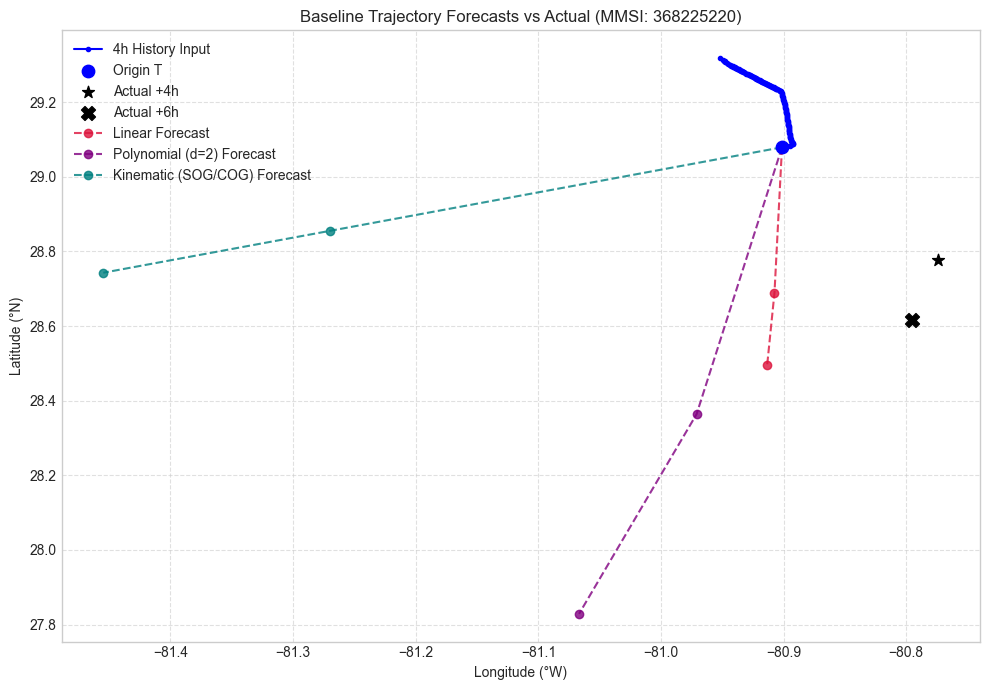

In [5]:
# Pick a representative validation sample
sample = val_w[5]
hist = sample.history_df

plt.figure(figsize=(10, 7))

# Plot historical trajectory
plt.plot(hist["longitude"], hist["latitude"], 'b.-', lw=1.5, label='4h History Input')
plt.scatter([sample.origin_lon], [sample.origin_lat], color='blue', s=80, marker='o', zorder=5, label='Origin T')

# Plot ground truth future points
plt.scatter([sample.target_4h["lon"]], [sample.target_4h["lat"]], color='black', s=80, marker='*', zorder=5, label='Actual +4h')
plt.scatter([sample.target_6h["lon"]], [sample.target_6h["lat"]], color='black', s=100, marker='X', zorder=5, label='Actual +6h')

colors = {"Linear": "crimson", "Polynomial (d=2)": "purple", "Kinematic (SOG/COG)": "teal"}

for name, model in models.items():
    preds = model.predict(hist, [4.0, 6.0])
    p4 = preds[4.0]
    p6 = preds[6.0]
    
    # Draw trajectory line from origin to predictions
    plt.plot([sample.origin_lon, p4[1], p6[1]], [sample.origin_lat, p4[0], p6[0]], 
             linestyle='--', marker='o', color=colors[name], alpha=0.8, label=f'{name} Forecast')

plt.title(f"Baseline Trajectory Forecasts vs Actual (MMSI: {sample.mmsi})", fontsize=12)
plt.xlabel("Longitude (°W)")
plt.ylabel("Latitude (°N)")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "baseline_trajectories_comparison.png"), dpi=150)
plt.show()


### Observational Notes on Baselines
1. **Kinematic SOG/COG vs Linear Extrapolation:**
   - Both models perform closely on steady open-water transit tracks because the onboard transponder COG aligns with the vessel's track angle over the ground.
   - However, when vessels make minor rudder adjustments near coastal traffic lanes, the instantaneous SOG/COG can deviate slightly from the broader track orientation. Averaging recent SOG/COG helps smooth this noise.
2. **Behavior of Quadratic Polynomial:**
   - On trajectories with steady turning (such as rounding Cape Canaveral or navigating the Florida Straits), degree-2 polynomial fitting can sometimes track curvature better.
   - However, if the vessel's history contains minor speed variations or noise, extrapolation over +4 to +6 hours accelerates outward quadratically, producing large outlier errors.
